# Visualize Voices and Sounds

In [18]:
%reload_ext autoreload
%autoreload 2

In [1]:
# Course utilities (do not modify this cell)
# Generated by post-canvas-notebooks. Edits above the marker are overwritten.
from pathlib import Path
import sys


def _find_courseutils():
    """Find courseutils no matter where the course repo was cloned."""
    here = Path.cwd().resolve()

    for parent in [here] + list(here.parents):
        for candidate in (parent / "courseutils",
                          parent / "Signals_and_Systems" / "courseutils"):
            if (candidate / "basic_material.py").is_file():
                return candidate.resolve()

    raise FileNotFoundError(
        "Could not find the 'courseutils' folder. Clone "
        "https://github.com/mit-acl/Signals_and_Systems and run this "
        "notebook from inside the cloned repository, then restart the kernel."
    )


COURSEUTILS_DIR = _find_courseutils()

# courseutils is used both as a folder of modules and as a package,
# since control_materials does "import courseutils.basic_material",
# so the folder and its parent both go on the path.
for _location in (COURSEUTILS_DIR.parent, COURSEUTILS_DIR):
    if str(_location) not in sys.path:
        sys.path.insert(0, str(_location))

for _folder in ("data", "figs"):
    Path(_folder).mkdir(exist_ok=True)

# --- end course setup ---

import basic_material as bm
bm.setup_environment()

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Audio/recording dependencies used by later cells
import os, time
import pyaudio, librosa
import scipy.io.wavfile as wav
from scipy.io.wavfile import write
import IPython.display as ipd

import warnings
warnings.filterwarnings(
    "ignore",
    message="divide by zero encountered in divide"
)
warnings.filterwarnings(
    "ignore",
    message="invalid value encountered in divide"
)

In [4]:
# store data
def store_data(signal,stack):
    # sum will treat Boolean True as a 1, False as a 0
    n = sum(os.path.isfile("data/"+name) for name in os.listdir('data/'))
    file_name = "data/Store_%s" % n 
    print("\nStoring recorded data in",file_name)

    np.savetxt(file_name+"_signal.csv", signal, delimiter=",")
    np.savetxt(file_name+"_stack.csv", stack, delimiter=",")

    signal_read = np.loadtxt(file_name+"_signal.csv",delimiter=',',skiprows=0)  
    stack_read = np.loadtxt(file_name+"_stack.csv",delimiter=',',skiprows=0)  

    print(f"Signal reload errors of {np.max(np.abs(signal_read - signal)):.6e}")
    print(f"Stack reload errors of {np.max(np.abs(stack_read - stack)):.6e}\n")
    
    return file_name

In [5]:
import sounddevice as sd

def start_multitone(freqs=(128, 256), duration=12, sr=44100, amp=0.20, device=None):
    t = np.arange(int(duration * sr)) / sr
    y = np.zeros_like(t, dtype=np.float32)

    for f in freqs:
        y += np.sin(2 * np.pi * f * t).astype(np.float32)

    y = amp * y / np.max(np.abs(y))

    # short fade to avoid clicks
    fade_n = int(0.01 * sr)
    fade = np.linspace(0, 1, fade_n, dtype=np.float32)
    y[:fade_n] *= fade
    y[-fade_n:] *= fade[::-1]

    sd.play(y, sr, blocking=False, device=device)
    return y

In [6]:
p = pyaudio.PyAudio()
device_keep_list = []
print("----------------------record device list---------------------")
info = p.get_host_api_info_by_index(0)
numdevices = info.get('deviceCount')
for i in range(0, numdevices):
        if (p.get_device_info_by_host_api_device_index(0, i).get('maxInputChannels')) > 0:
            print("Input Device id ", i, " - ", p.get_device_info_by_host_api_device_index(0, i).get('name'))
            if (p.get_device_info_by_host_api_device_index(0, i).get('name')[0:7] == 'MacBook'):
                device_keep_list = np.append(device_keep_list,i)

print("-------------------------------------------------------------")

if isinstance(device_keep_list, list) and len(device_keep_list) > 0:
    device_keep_list = device_keep_list[0]
print("Using this microphone: ",p.get_device_info_by_host_api_device_index(0, int(device_keep_list[0]))['name'][:7] if len(device_keep_list) > 0 else 'NoDevice')


----------------------record device list---------------------
Input Device id  1  -  JHow72 Microphone
Input Device id  2  -  LG UltraFine Display Audio
Input Device id  4  -  HD Pro Webcam C920
Input Device id  5  -  MacBook Pro Microphone
Input Device id  7  -  Camo Microphone
Input Device id  8  -  Microsoft Teams Audio
Input Device id  9  -  ZoomAudioDevice
-------------------------------------------------------------
Using this microphone:  MacBook


## Collect Microphone data

In [7]:
sr = 44100
tf = 12
chunk_size = sr // 4
fmax = 1024
n_chunks = int(np.ceil(tf * sr / chunk_size))
freqs = [128, 160, 192, 320]

# Start the speaker tone a little longer than the recording
tone = start_multitone(
    freqs=freqs,
    duration=tf + 5,
    sr=sr,
    amp=0.25,
)

time.sleep(0.5)  # give speaker output time to start

alldata = []

stream = p.open(
    format=pyaudio.paFloat32,
    channels=1,
    rate=sr,
    input=True,
    input_device_index=device_keep_list,
    frames_per_buffer=chunk_size,
)

t0 = time.time()

for k in range(n_chunks):
    data = stream.read(chunk_size, exception_on_overflow=False)
    DATA = np.frombuffer(data, dtype=np.float32)
    alldata.append(DATA)
    print(f"{(k+1)*chunk_size/sr:.1f} ", end="\n" if (k + 1) % 24 == 0 else "")

elapsed = time.time() - t0

stream.stop_stream()
stream.close()
sd.stop()

signal = np.hstack(alldata)[:int(tf * sr)]

print("\nactual duration:", len(signal) / sr)
print(f"wall duration: {elapsed:.1f} seconds, {elapsed/tf:.2f}x real time")

# Compute mel spectrogram after recording
melspec = librosa.feature.melspectrogram(
    y=signal,
    sr=sr,
    n_mels=100,
    fmax=fmax,
    n_fft=4096,
    hop_length=512,
)

stack = librosa.power_to_db(melspec, ref=np.max)

stored_file_names = store_data(signal, stack)

0.2 0.5 0.8 1.0 1.2 1.5 1.8 2.0 2.2 2.5 2.8 3.0 3.2 3.5 3.8 4.0 4.2 4.5 4.8 5.0 5.2 5.5 5.8 6.0 
6.2 6.5 6.8 7.0 7.2 7.5 7.8 8.0 8.2 8.5 8.8 9.0 9.2 9.5 9.8 10.0 10.2 10.5 10.8 11.0 11.2 11.5 11.8 12.0 

actual duration: 12.0
wall duration: 12.0 seconds, 1.00x real time

Storing recorded data in data/Store_449
Signal reload errors of 0.000000e+00
Stack reload errors of 0.000000e+00



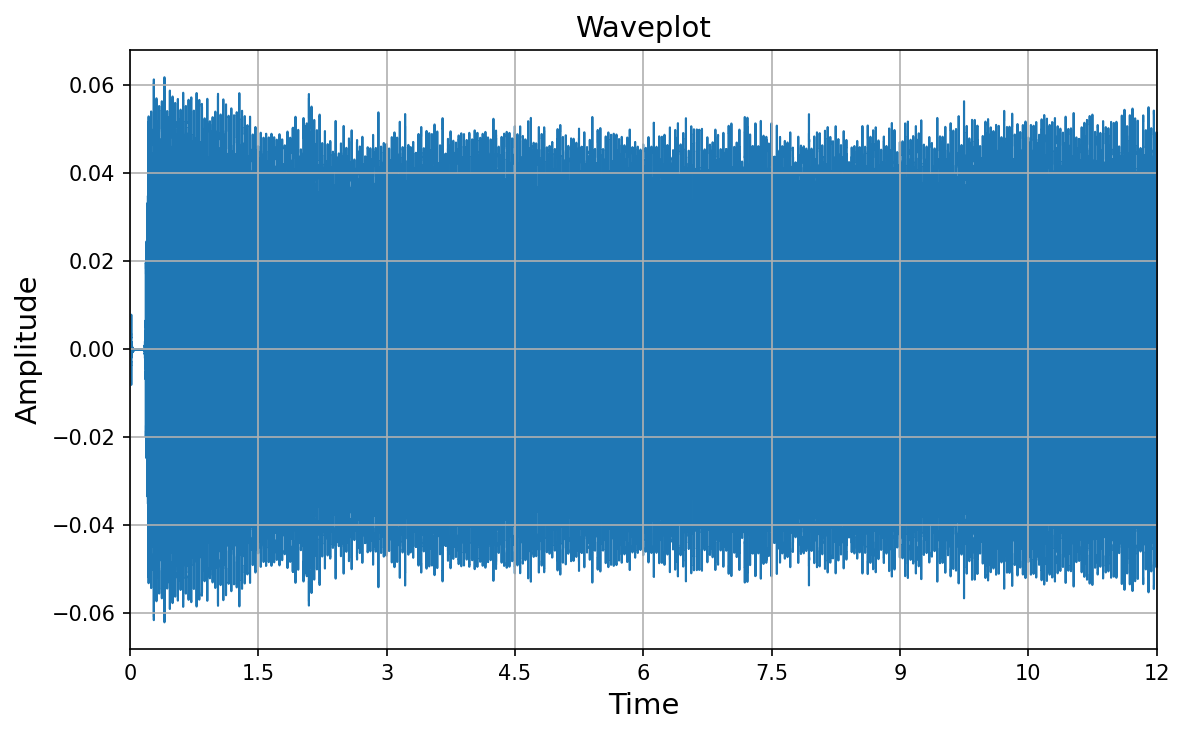

Signal saved as 'data/Store_449.wav'


In [8]:
plt.figure(figsize=(8, 5))
librosa.display.waveshow(signal, sr=sr)
plt.title('Waveplot', fontdict=dict(size=14))
plt.xlabel('Time', fontdict=dict(size=14))
plt.ylabel('Amplitude', fontdict=dict(size=14))
plt.xlim(0,tf)
plt.savefig('./figs/mic_0.png', bbox_inches='tight', dpi=300)
plt.show()

# Normalize the signal to the range of int16
Signal = np.int16(signal / np.max(np.abs(signal)) * 32767)

# Save the signal as a WAV file
write(stored_file_names+'.wav', sr, Signal)

print(f"Signal saved as '{stored_file_names+'.wav'}'")


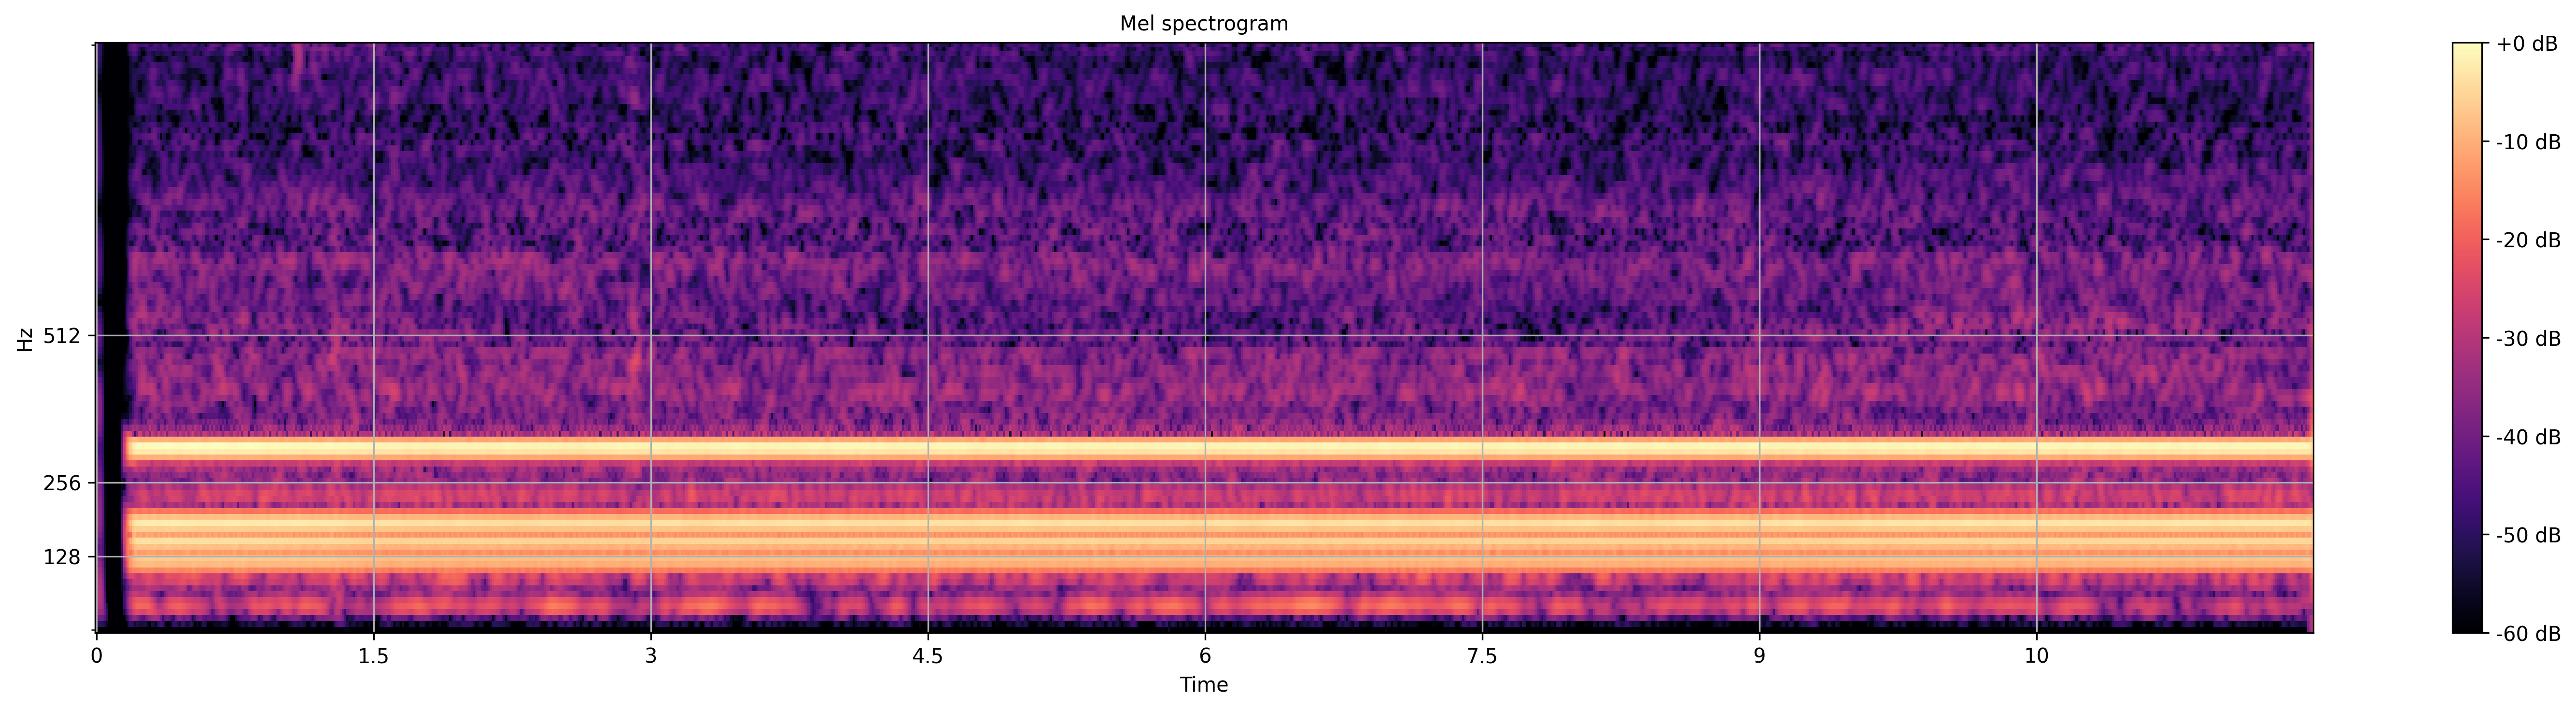

In [9]:
plt.figure(1,figsize=(20, 5),dpi=300)
librosa.display.specshow(stack, y_axis='mel', sr=sr, fmin = 0, fmax = fmax, hop_length=512, x_axis='time')
plt.colorbar(format='%+2.0f dB')
plt.title('Mel spectrogram')
plt.clim(-60, 0)
yticks = [128, 256, 512]
plt.yticks(yticks, [str(y) for y in yticks])

plt.savefig('./figs/mic_1.png', bbox_inches='tight', dpi=300)
plt.show()

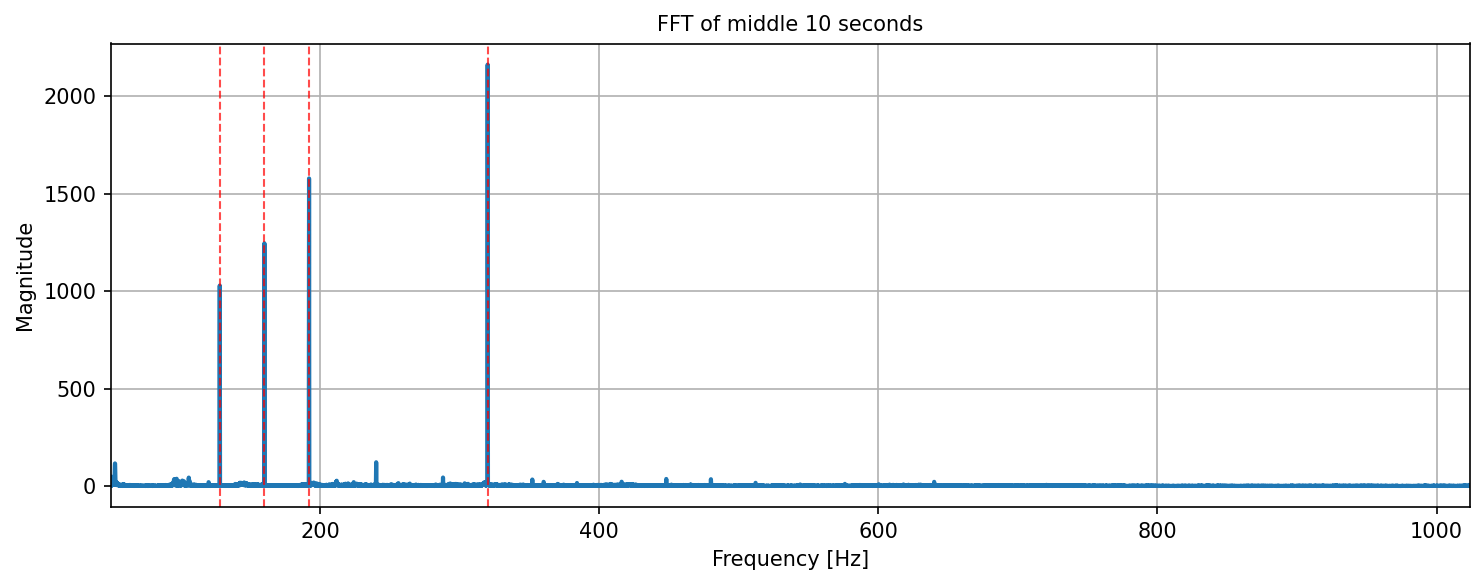

In [10]:
x = signal[int(1*sr):int(11*sr)]  # remove first/last second

window = np.hanning(len(x))
Y = np.fft.rfft(x * window)
freq_axis = np.fft.rfftfreq(len(x), d=1/sr)
mag = np.abs(Y)

mask = (freq_axis >= 50) & (freq_axis <= fmax)

plt.figure(figsize=(10, 4), dpi=150)
plt.plot(freq_axis[mask], mag[mask])
plt.xlim(50, fmax)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude")
plt.title("FFT of middle 10 seconds")
plt.grid(True)

for f in freqs:
    plt.axvline(f, color="r", linestyle="--", linewidth=1, alpha=0.7)
plt.show()

## Try some sample cases

In [11]:
def plotdata(titledata):
    plt.figure(figsize=(12, 5),dpi=300)
    librosa.display.waveshow(signal, sr=sr)
    plt.title(titledata, fontdict=dict(size=18))
    plt.xlabel('Time', fontdict=dict(size=15))
    plt.ylabel('Amplitude', fontdict=dict(size=15))
    fname = ['./figs/'+titledata+'_0.png'] 
    plt.savefig(str(fname[0]), bbox_inches='tight', dpi=300)
    plt.show()

    mel_signal = librosa.feature.melspectrogram(y=signal, sr=sr, hop_length=hop_length, n_fft=n_fft)
    power_to_db = librosa.power_to_db(np.abs(mel_signal), ref=np.max)

    plt.figure(figsize=(20, 5),dpi=300)
    librosa.display.specshow(power_to_db, sr=sr, x_axis='time', y_axis='mel', cmap='magma', hop_length=hop_length)
    plt.colorbar(label='dB')
    plt.title('Mel-Spectrogram (dB)', fontdict=dict(size=18))
    plt.xlabel('Time', fontdict=dict(size=18))
    plt.ylabel('Frequency', fontdict=dict(size=18))
    fname = ['./data/'+titledata+'_1.png'] 
    plt.savefig(str(fname[0]), bbox_inches='tight', dpi=300)
    plt.show()

In [12]:
# Parameters for the algorithms
n_fft = 2048      # this is the number of samples in a window per fft
hop_length = 512  # The amount of samples we are shifting after each fft

In [13]:
signal, sr = librosa.load(librosa.util.example('trumpet'))
ipd.Audio(signal, rate=sr)

[audio/animation output removed to keep the repository small - run this cell to generate it]

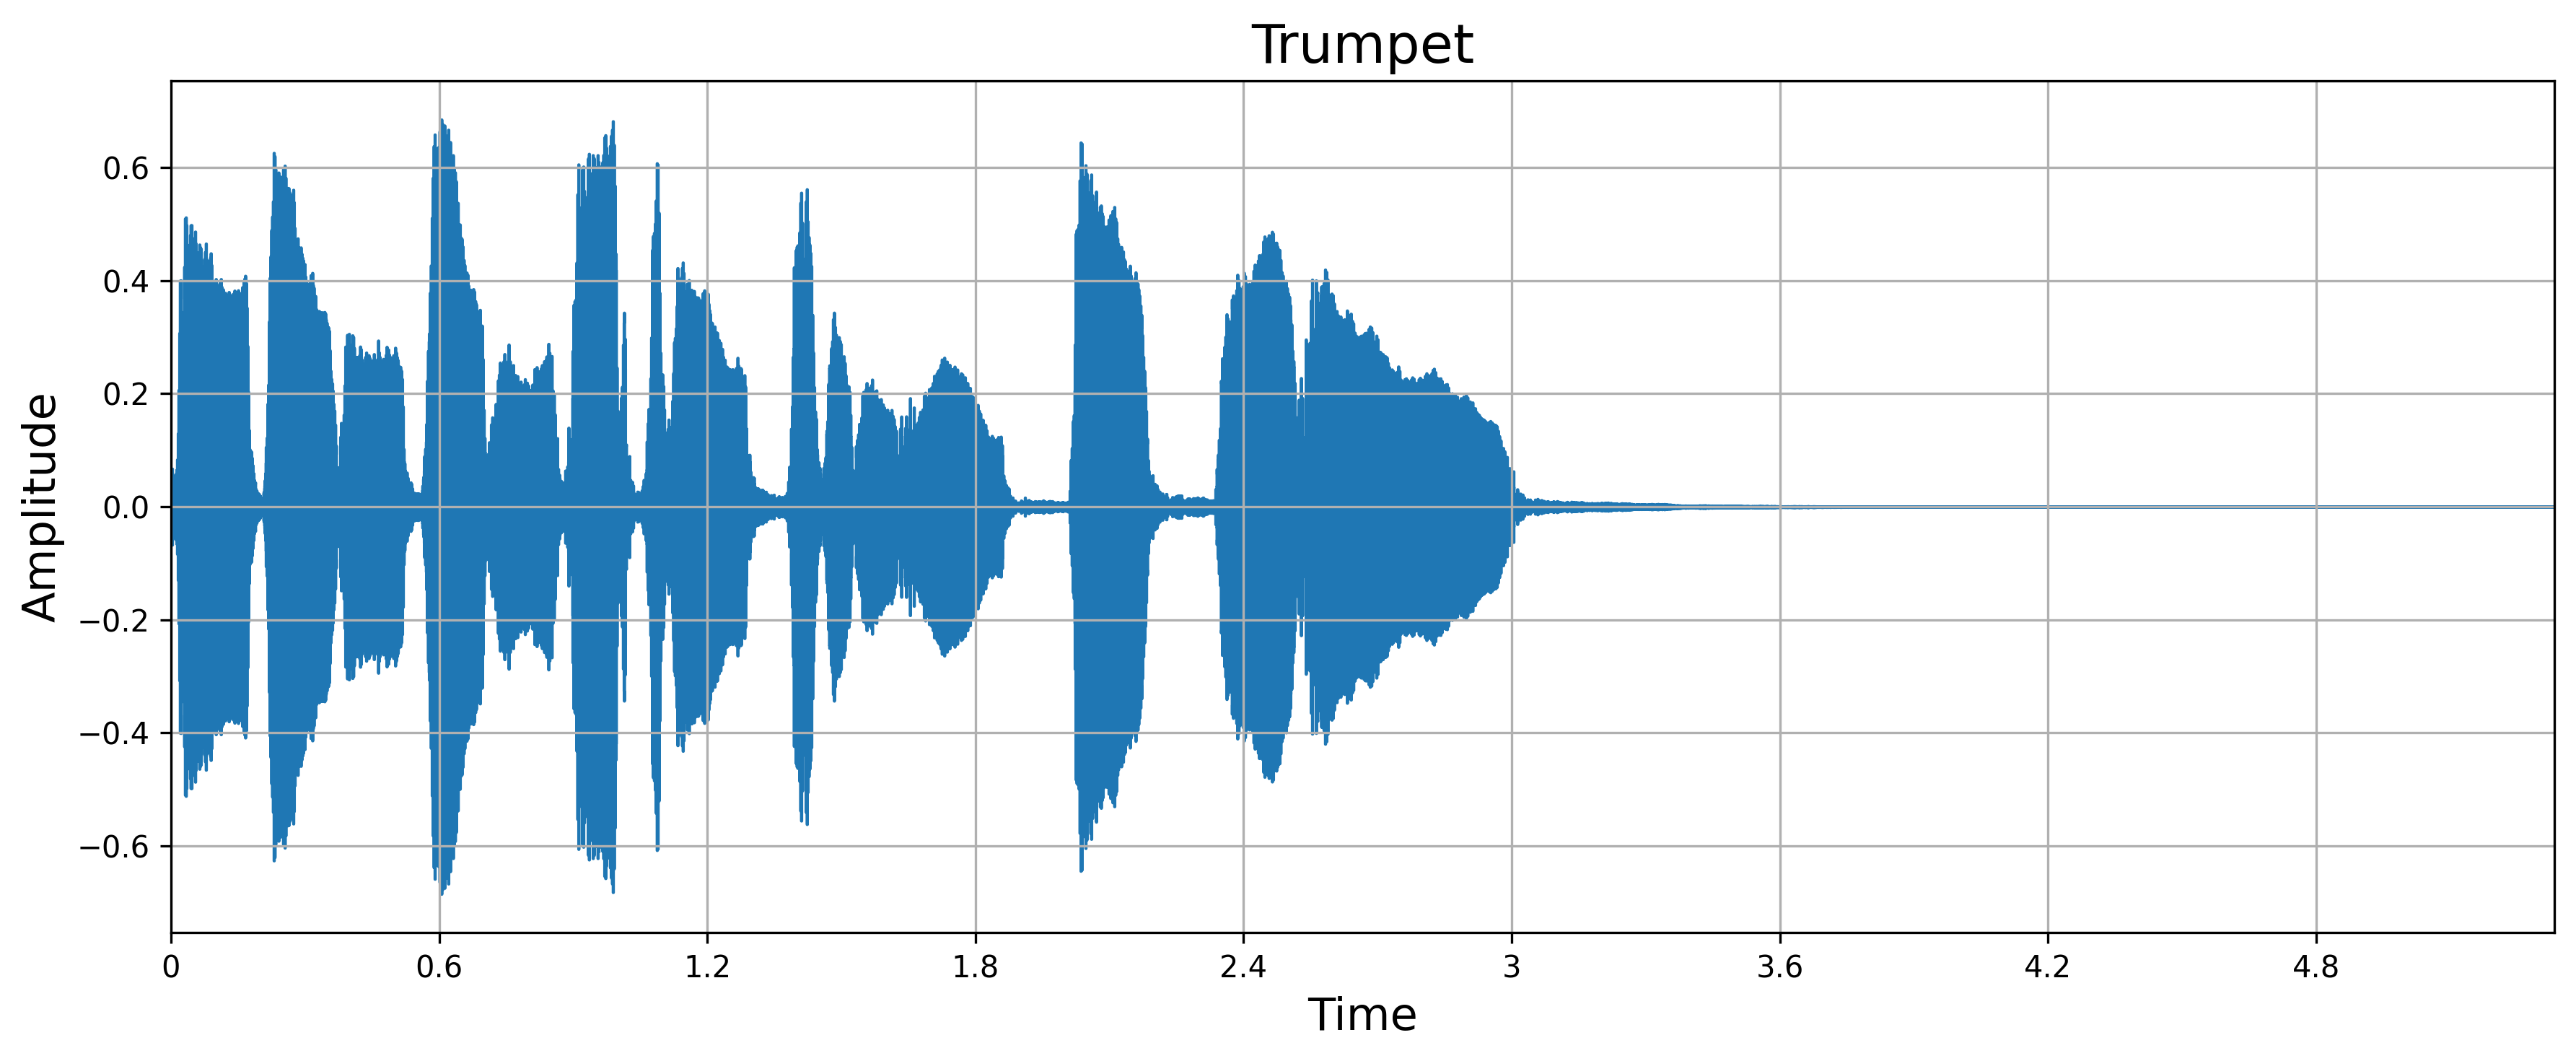

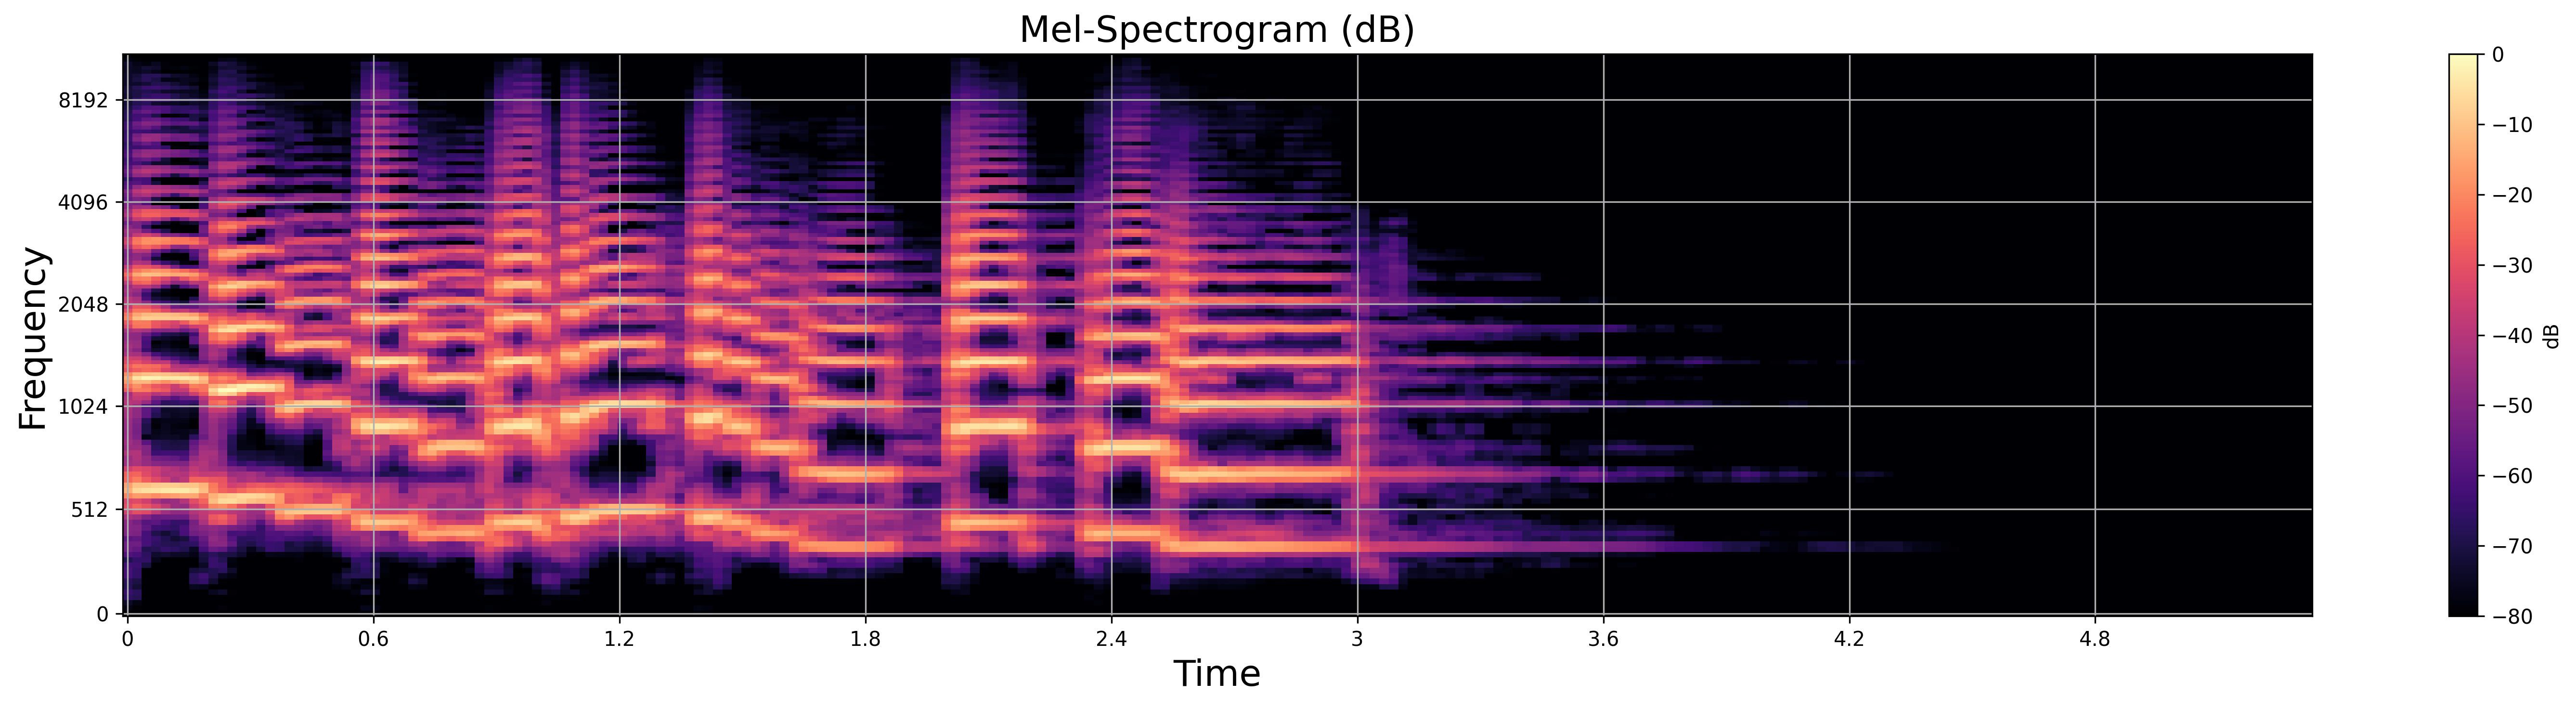

In [14]:
h = plotdata('Trumpet')

In [15]:
signal, sr = librosa.load(librosa.util.example('pistachio'))
ipd.Audio(signal, rate=sr)

[audio/animation output removed to keep the repository small - run this cell to generate it]

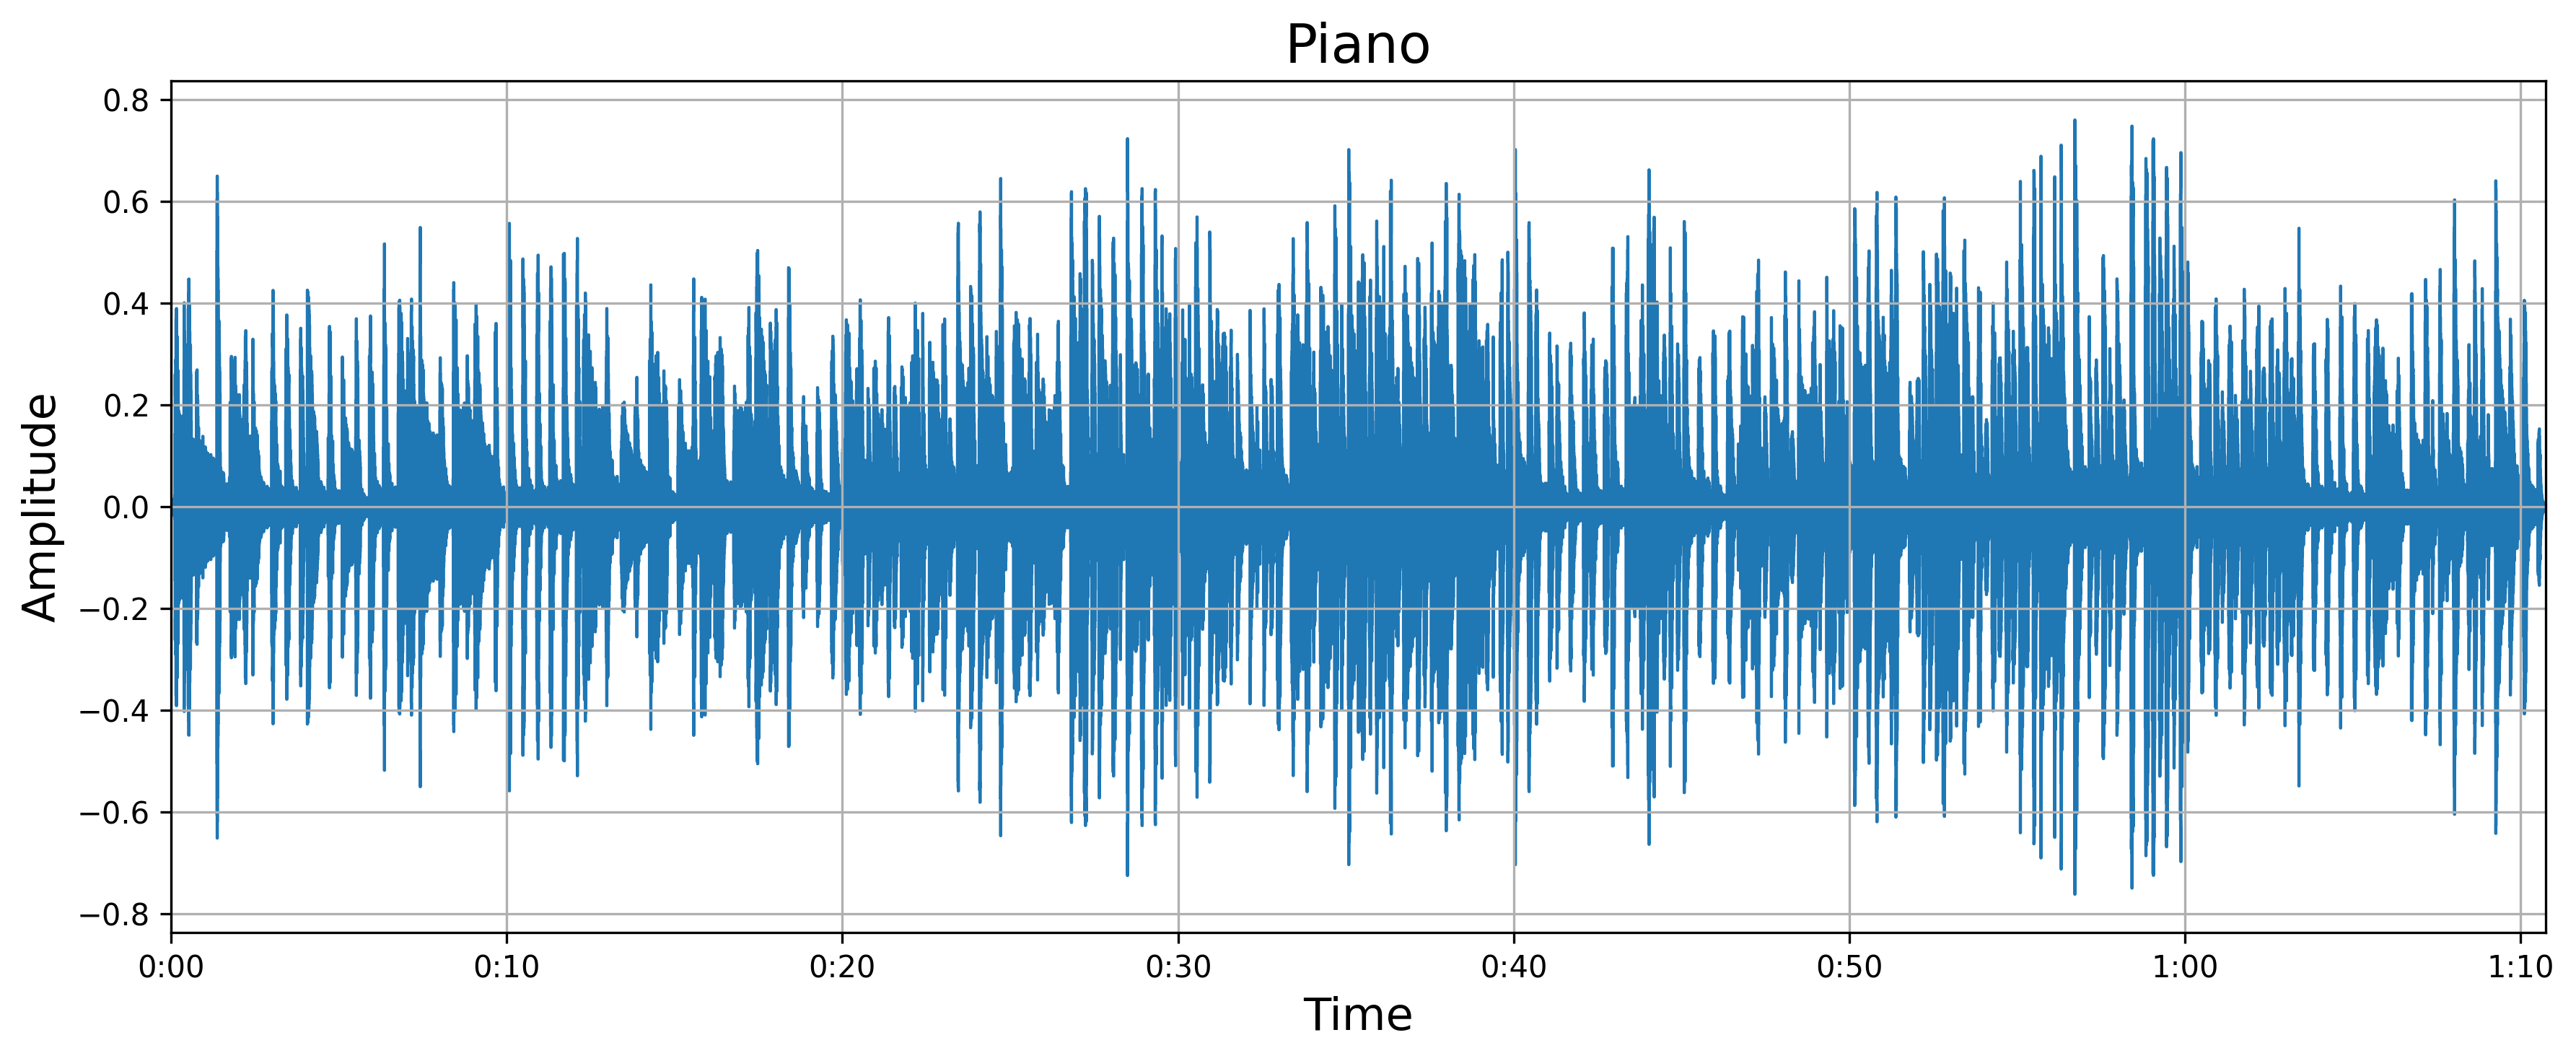

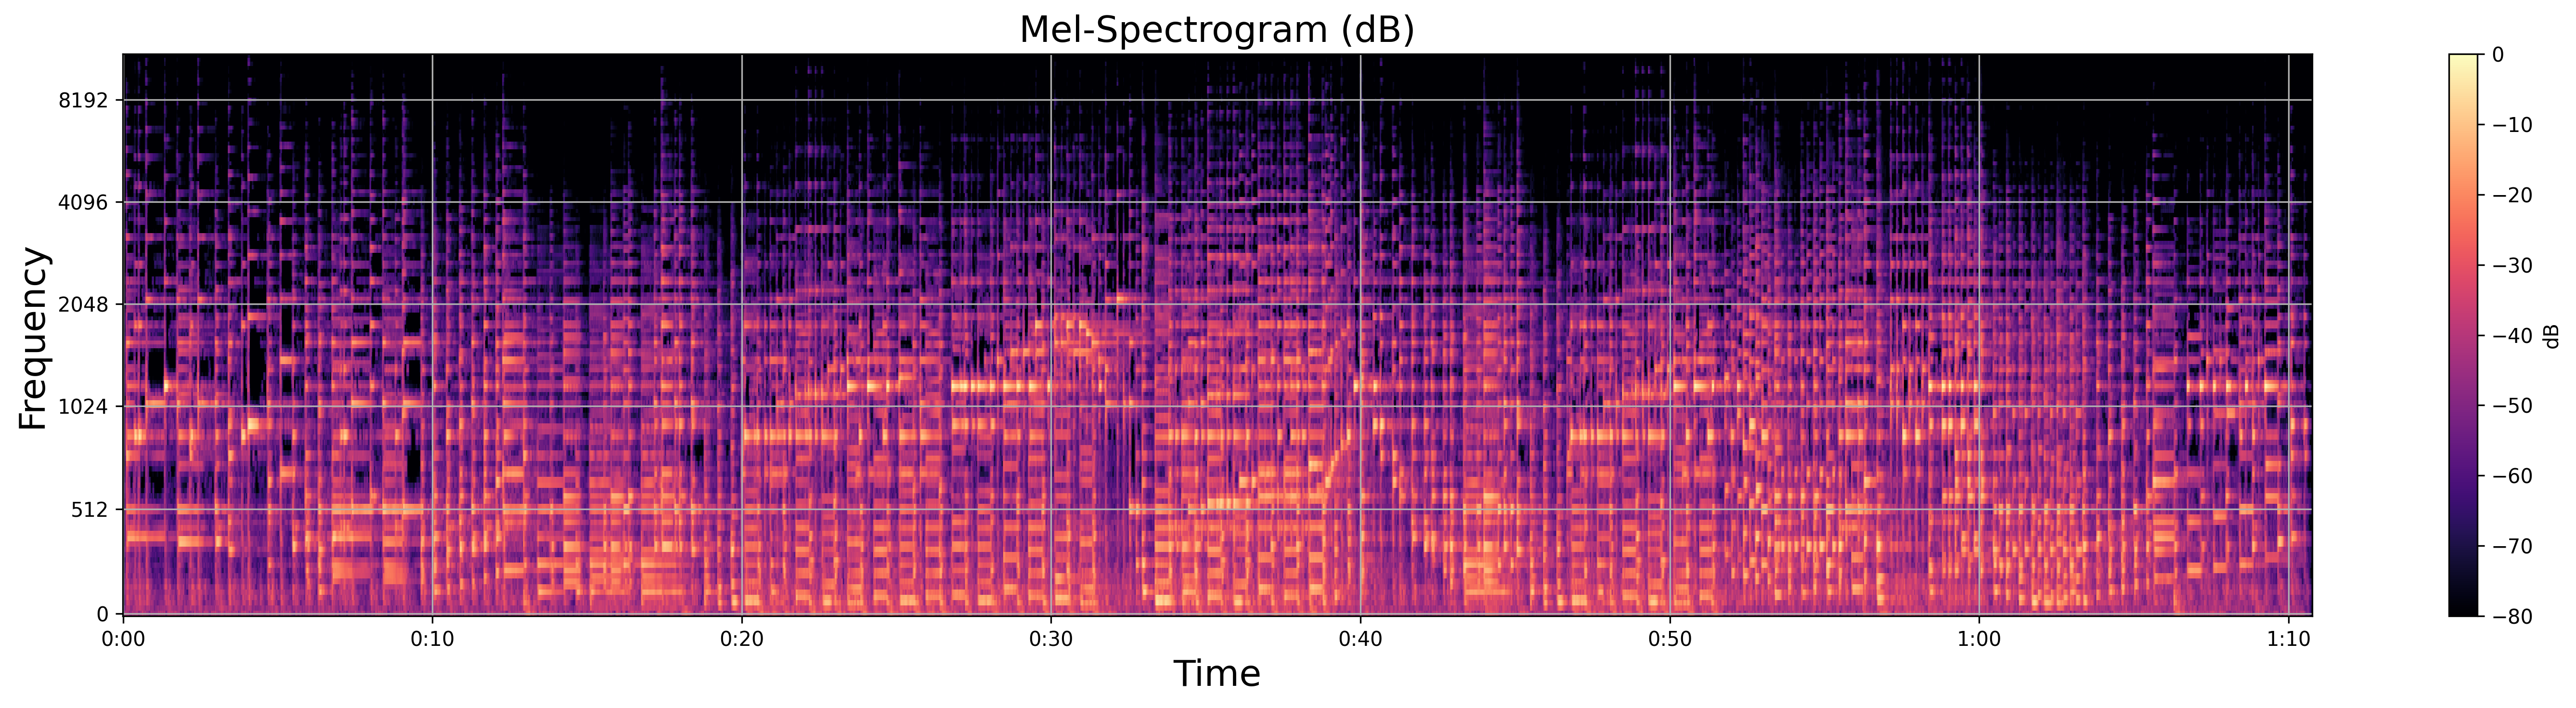

In [16]:
plotdata('Piano')

In [17]:
signal, sr = librosa.load(librosa.util.example('humpback'))
ipd.Audio(signal, rate=sr)

[audio/animation output removed to keep the repository small - run this cell to generate it]

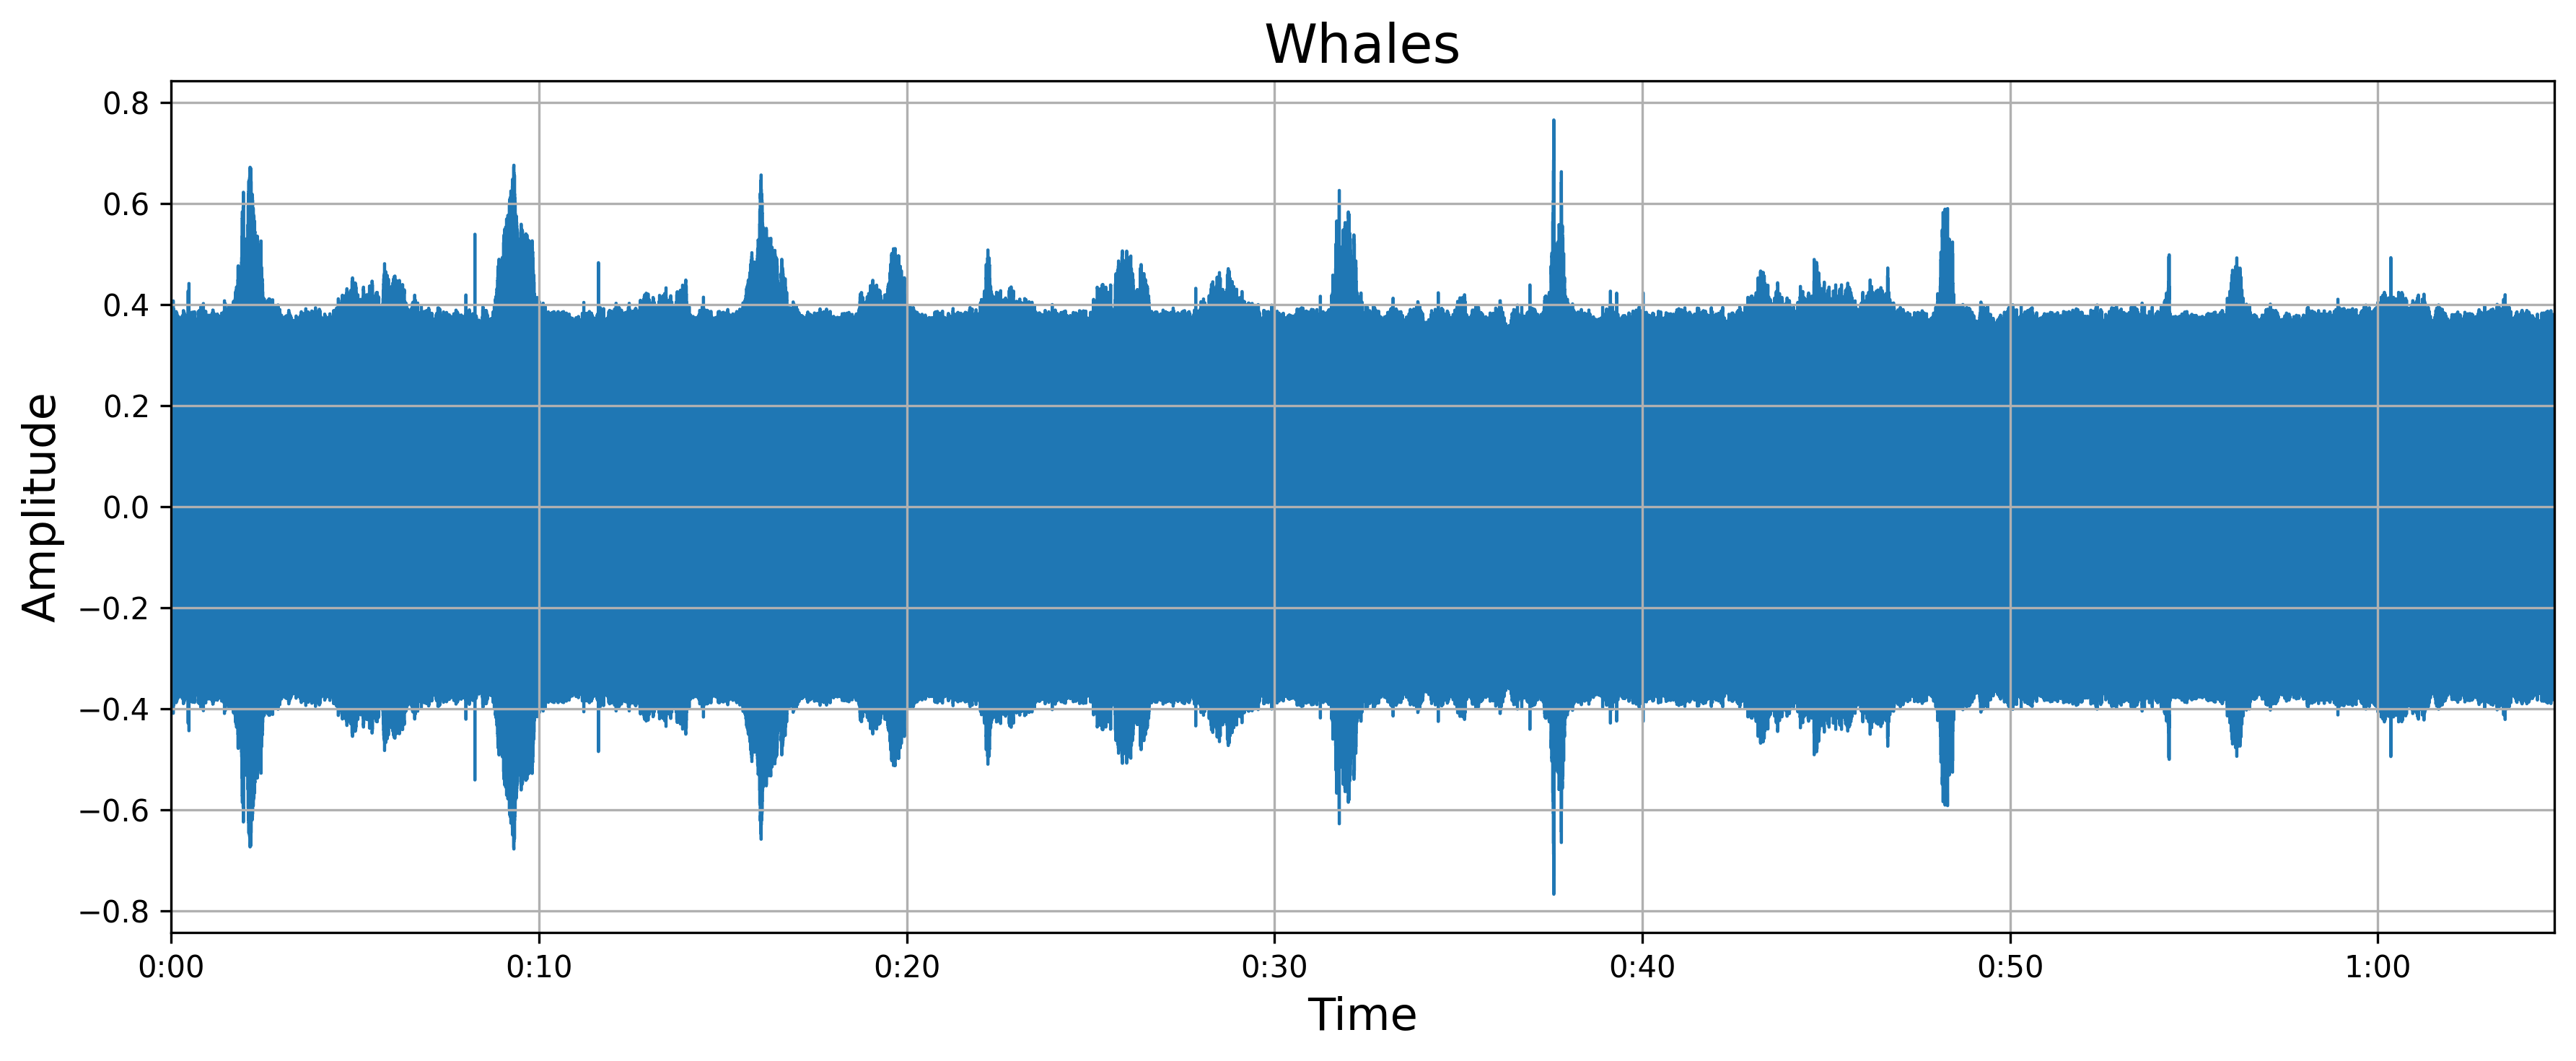

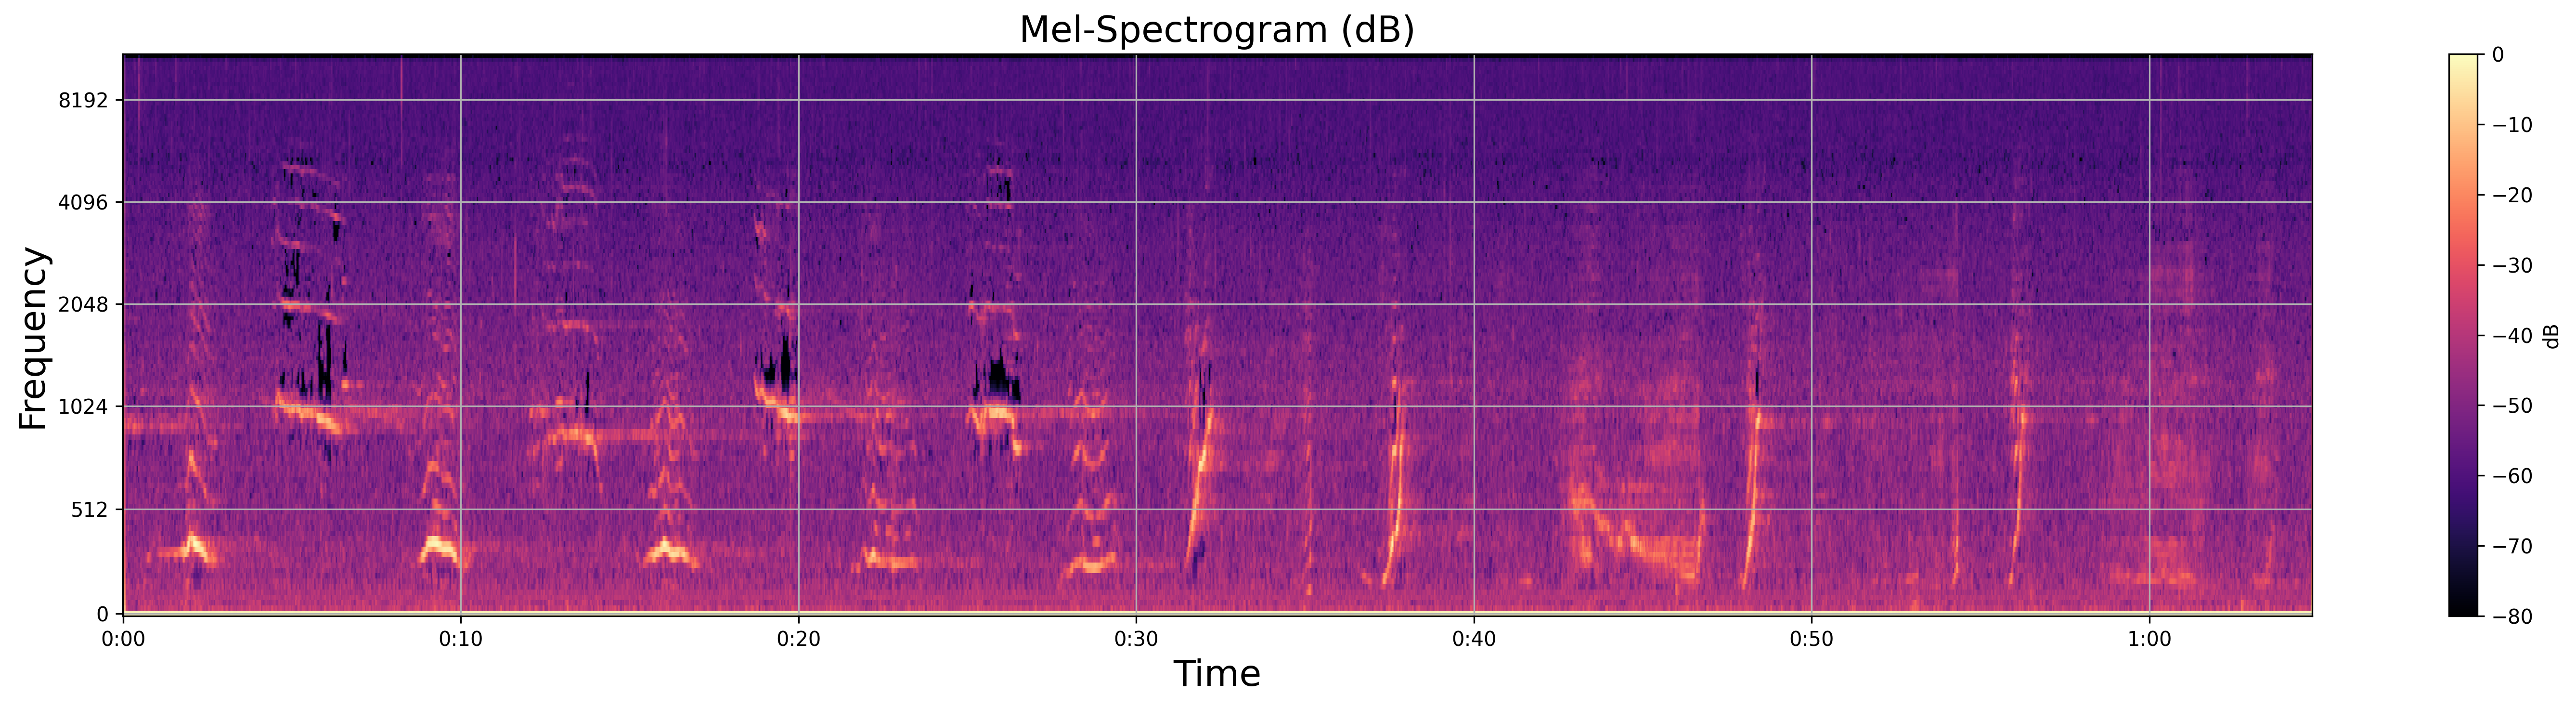

In [18]:
plotdata('Whales')